## draw_storm_features.ipynb
Author: Robby M. Frost

Organization: OU Advanced Radar Research Center

Created: 14 July 2025

Purpose: Draw vortex location on PPI scans

In [1]:
import pyart
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib import rc
import sys
from mpl_point_clicker import clicker
from matplotlib.ticker import MultipleLocator
sys.path.append('/home/robbyfrost/Analysis/TurbTor_Radar/')
from functions import *
import os
import glob

# plotting set up
plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams['text.latex.preamble'] = r'\usepackage{bm}'
rc('font', family='sans-serif')
rc('font', weight='normal', size=6)
rc('figure', facecolor='white')
rc('axes', titlesize=8)

%matplotlib ipympl


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



Plotting functions

In [2]:
# PPI plotting function
def plot_ppi(radar, tstring):
    """
    Plot RaXPol PPI

    :param dict radar: pyart radar object
    :param str tstring: time string for plotting
    """
    display = pyart.graph.RadarDisplay(radar.extract_sweeps([0]))
    xlims = [-2,8]
    ylims = [0,10]

    fig, axs = plt.subplots(figsize=(6,3.5), 
                            ncols=2,
                            constrained_layout=True,
                            dpi=150,
                            sharey=True)

    fig.suptitle(f"{radar.metadata['instrument_name']} {tstring} UTC (El={radar.fixed_angle['data'][0]:.1f}$^{{\\circ}}$)", 
                fontsize=10, 
                fontweight='bold')

    # reflectivity
    ax = axs[0]
    vmin, vmax = -10, 70
    display.plot_ppi('DBZ_ADJ', ax=ax, 
                    vmin=vmin, vmax=vmax,
                    cmap="Carbone42",
                    colorbar_flag=False,
                    title_use_sweep_time=False,
                    axislabels_flag=False)
    ax.set_title("Equivalent Reflectivity Factor")
    cbar0 = fig.colorbar(display.plots[0], ax=ax, orientation='horizontal', pad=0.015)
    cbar0.set_label("$Z$ [dBZ]")
    cbar0.set_ticks(np.arange(vmin, vmax + 0.001, 10))
    ax.set_ylabel("Meridional Distance [km]")
    # radial velocity
    ax = axs[1]
    vmin, vmax = -50, 50
    display.plot_ppi('VELDEL', ax=ax, 
                    vmin=vmin, vmax=vmax,
                    cmap="Carbone42",
                    colorbar_flag=False,
                    title_use_sweep_time=False,
                    axislabels_flag=False)
    ax.set_title("Radial Velocity")
    cbar2 = fig.colorbar(display.plots[1], ax=ax, orientation='horizontal', pad=0.015)
    cbar2.set_label("$V_r$ [m s$^{-1}$]")
    cbar2.set_ticks(np.arange(vmin, vmax + 0.001, 10))

    # clean up plot
    for iax in axs.flatten():
        iax.set_aspect('equal')
        iax.set_xlim(xlims)
        iax.xaxis.set_major_locator(MultipleLocator(2))
        iax.xaxis.set_minor_locator(MultipleLocator(0.5))
        iax.set_xlabel("Zonal Distance [km]")
        iax.set_ylim(ylims)
        iax.yaxis.set_major_locator(MultipleLocator(2))
        iax.yaxis.set_minor_locator(MultipleLocator(0.5))
        iax.grid(alpha=0.6)

    return fig, axs

Read in radar

In [11]:
# path to radar data
drad = "/data/arrcwx/wrt_jtrf/morton/grf/bf2/"
# path to output vortex positions
dvort = "/data/arrcwx/wrt_jtrf/morton/sa/"


# desired time
jt = 18


# time strings
ffiles = sorted(glob.glob(f"{drad}DEALIASED*"))
files = [os.path.basename(f) for f in ffiles]
tstrings = [f[17:32] for f in files]
tstring = tstrings[jt]

# read in radar data
radar = pyart.io.read(ffiles[jt])

In [12]:
tstring

'20250605-224037'

## Vortex position

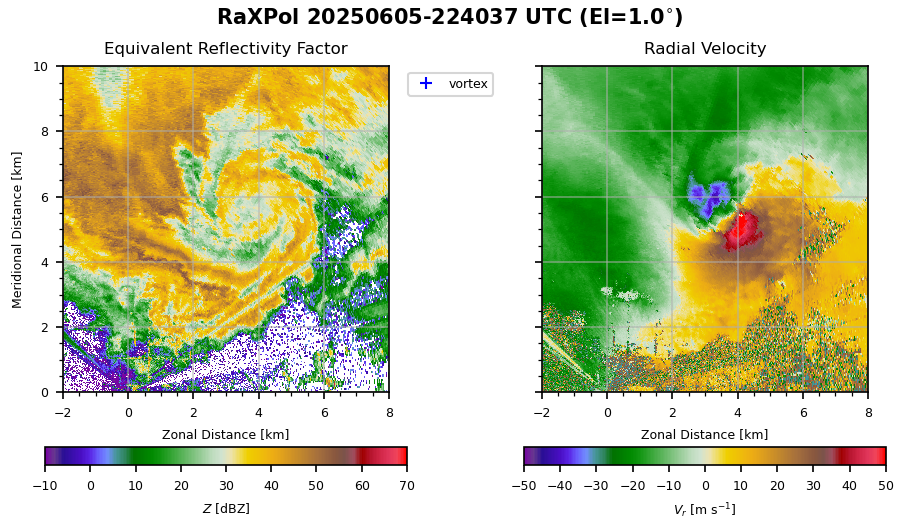

In [13]:
# make fig
fig, axs = plot_ppi(radar, tstring)
# locate vortex
klicker = clicker(axs[0], ["vortex"], markers=["+"], colors='black')
plt.show()

In [14]:
plt.close(fig)
vortex_coords = klicker.get_positions()['vortex']
rx, ry = vortex_coords[:,0], vortex_coords[:,1]

outdir = f"{dvort}vortex-{tstring}.txt"
np.savetxt(outdir, np.column_stack([rx,ry]), delimiter=',', header='X positions [km], Y positions [km]', comments='')
print(f"Vortex coordinates saved to: {outdir}")

Vortex coordinates saved to: /data/arrcwx/wrt_jtrf/morton/sa/vortex-20250605-224037.txt
